# Recommendation system

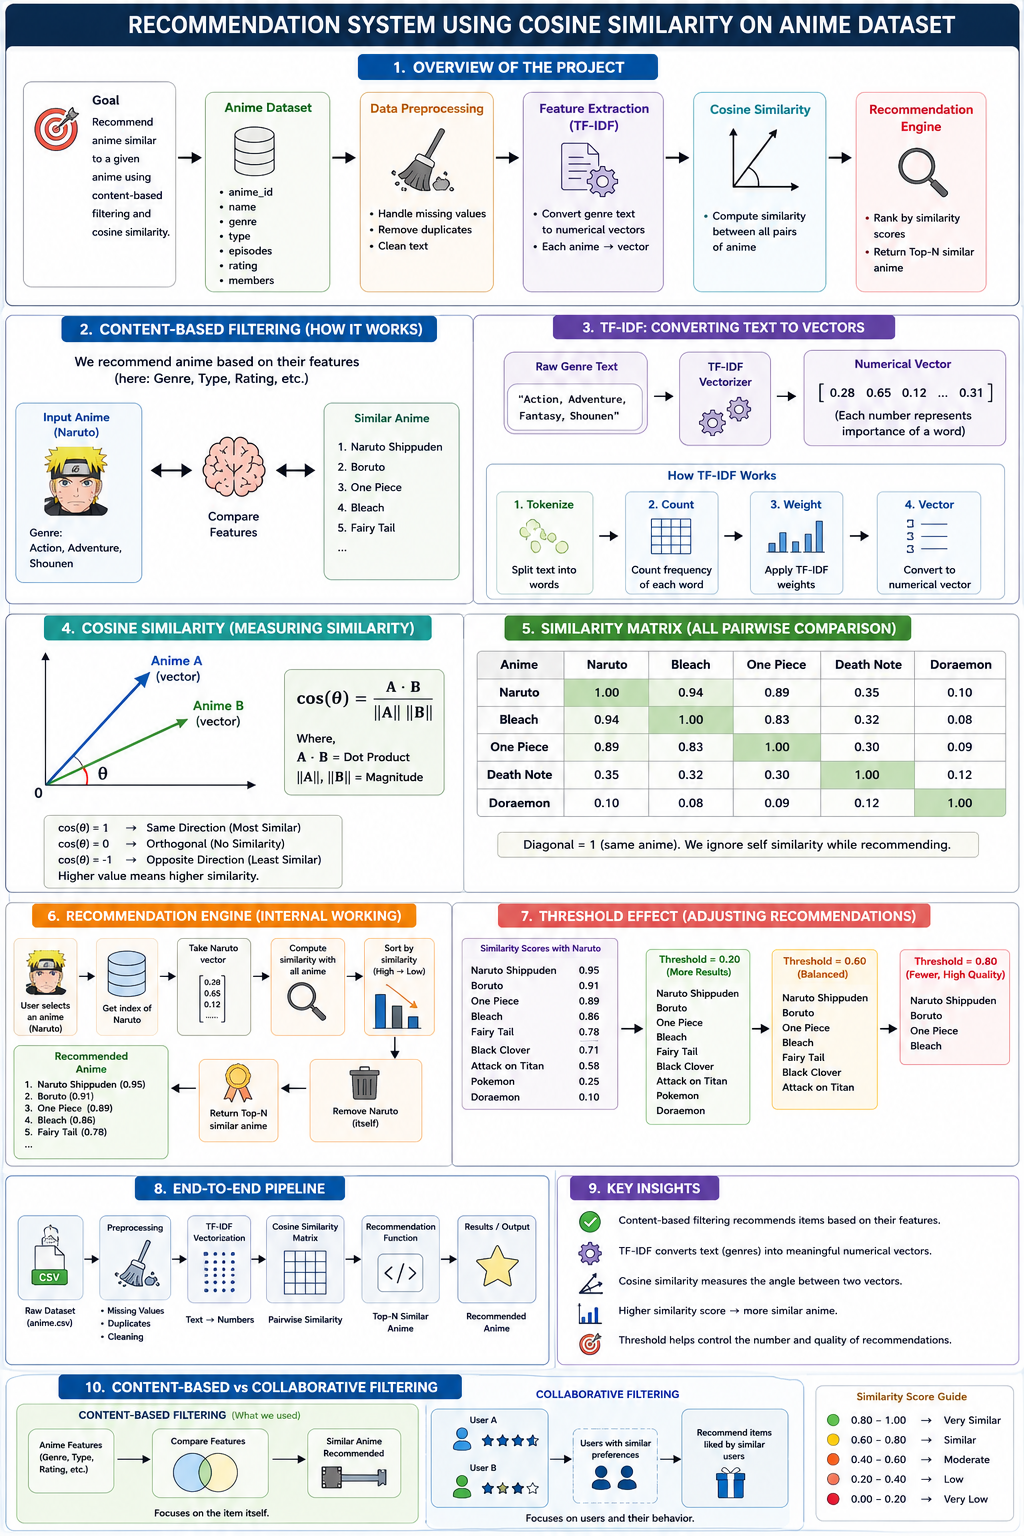

                Anime Dataset
                      │
                      ▼
            Data Preprocessing
                      │
                      ▼
            Handle Missing Values
                      │
                      ▼
           Remove Duplicate Rows
                      │
                      ▼
             Genre Feature Selected
                      │
                      ▼
               TF-IDF Vectorization
                      │
                      ▼
              Cosine Similarity Matrix
                      │
                      ▼
           Recommendation Function
                      │
                      ▼
        Top Similar Anime Returned

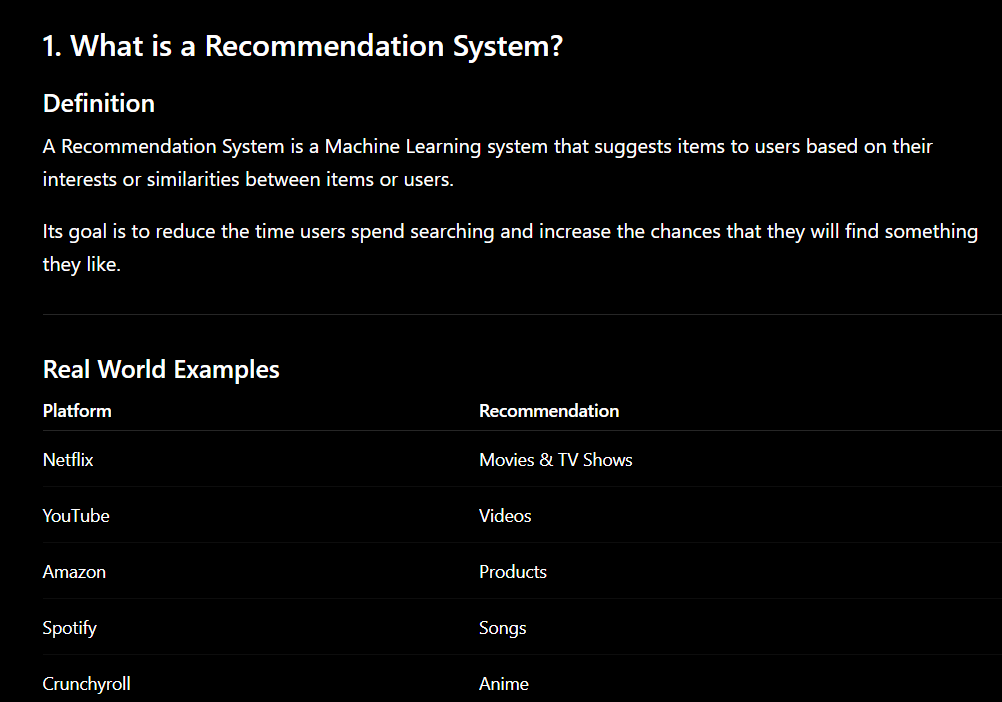

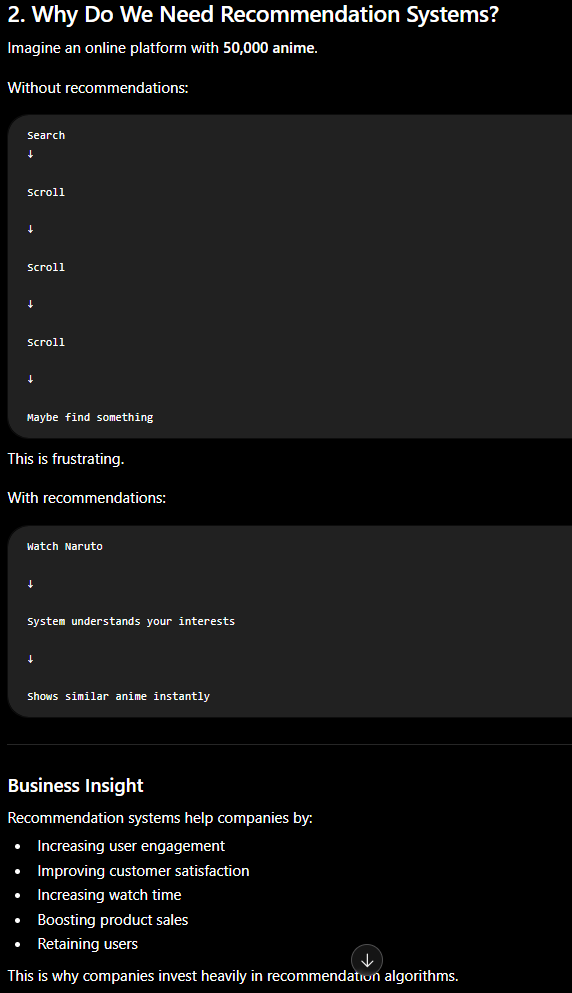

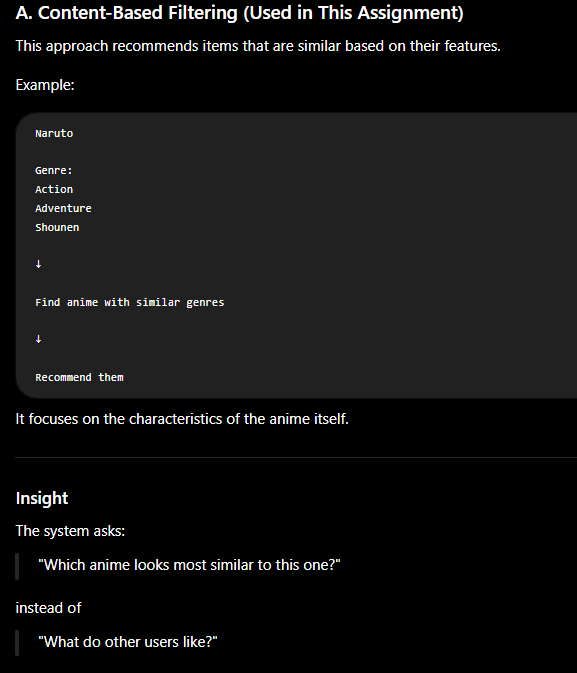

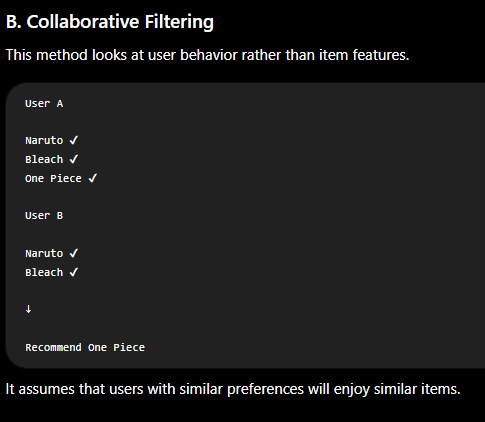

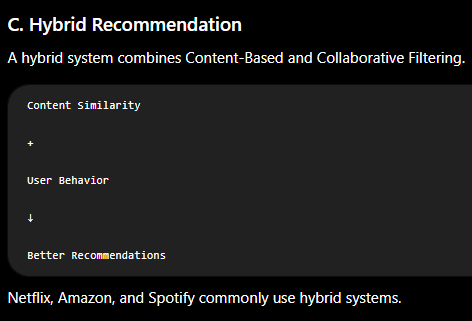

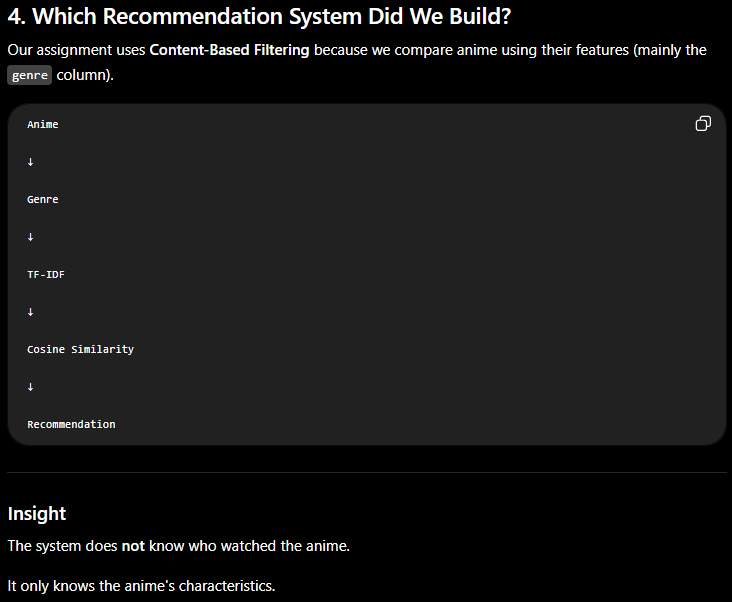

In [97]:

# Import Required Libraries


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [98]:

df = pd.read_csv("anime.csv")

df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [69]:
df.shape

(12294, 7)

In [70]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [99]:

# Statistical Summary

df.describe(include="all")

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Saru Kani Gassen,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [73]:

# Missing Values


df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [74]:

# Handle Missing Values

# Replace missing genres with Unknown
df["genre"] = df["genre"].fillna("Unknown")

# Replace missing type with Unknown
df["type"] = df["type"].fillna("Unknown")

# Replace missing ratings with median
df["rating"] = df["rating"].fillna(df["rating"].median())

In [75]:

# Check Missing Values Again

df.isnull().sum()

,0
anime_id,0
name,0
genre,0
type,0
episodes,0
rating,0
members,0


In [76]:
df.duplicated().sum()

np.int64(0)

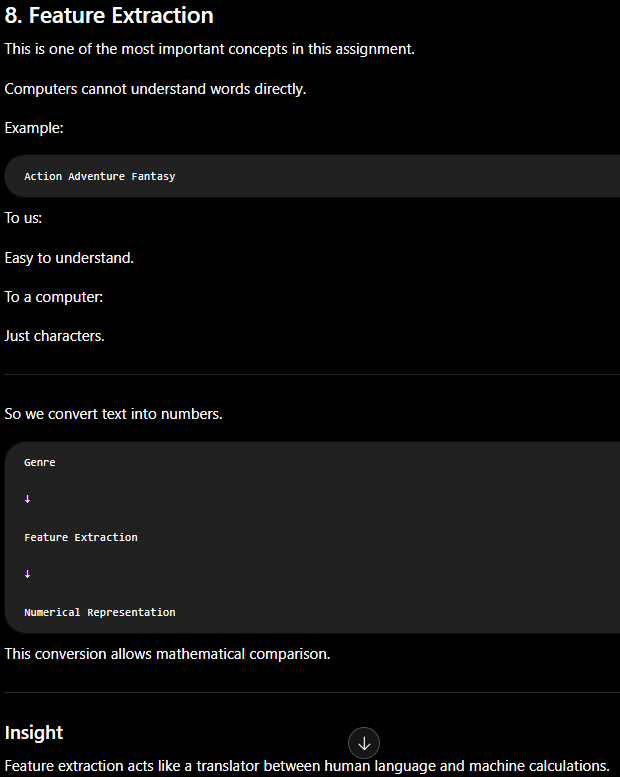

In [77]:

# Display Genre Column

df["genre"].head()

,genre
0,"Drama, Romance, School, Supernatural"
1,"Action, Adventure, Drama, Fantasy, Magic, Mili..."
2,"Action, Comedy, Historical, Parody, Samurai, S..."
3,"Sci-Fi, Thriller"
4,"Action, Comedy, Historical, Parody, Samurai, S..."


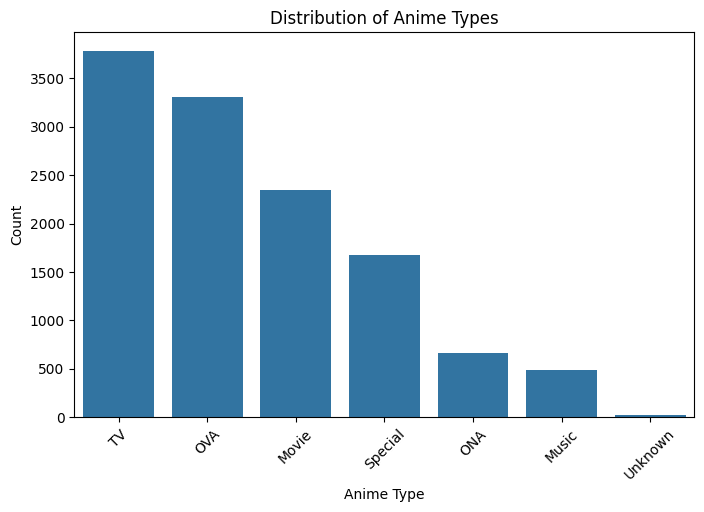

In [78]:

# Distribution of Anime Types

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Distribution of Anime Types")
plt.xlabel("Anime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

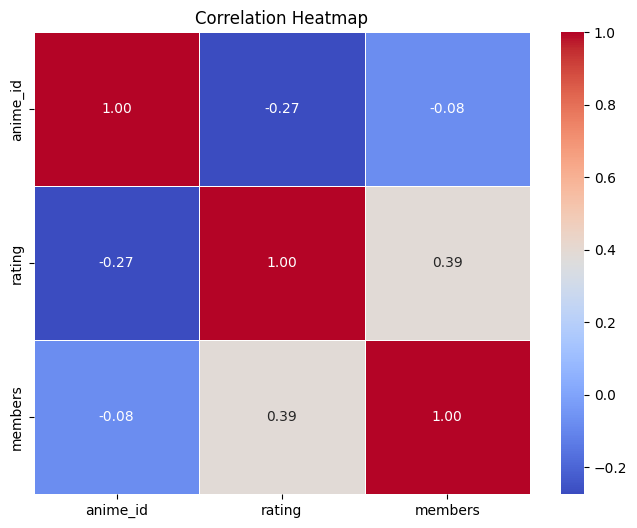

In [79]:

# Correlation Heatmap

# Select only numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation_matrix = numerical_columns.corr()

# Plot Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Display correlation values
    cmap="coolwarm",     # Color palette
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

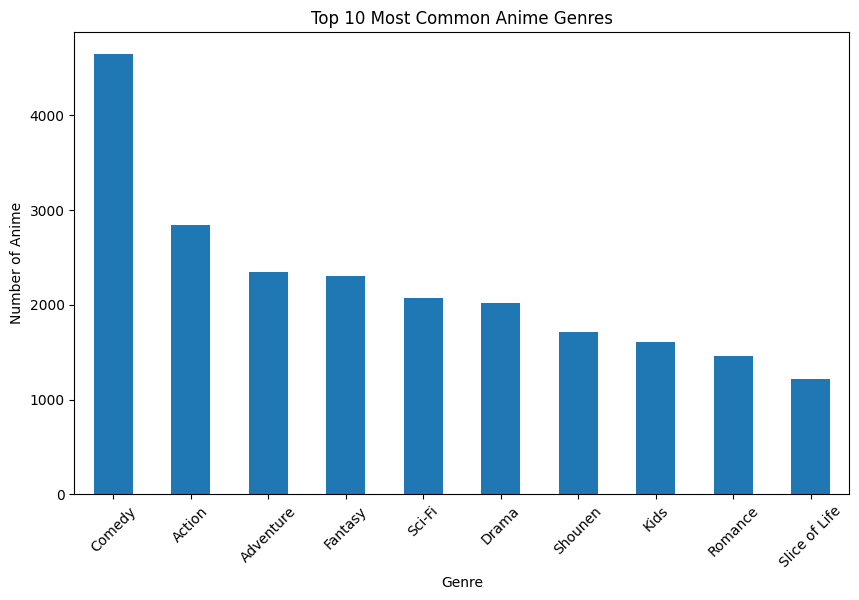

In [80]:

# Top 10 Most Common Genres

# Split all genres into individual values
genres = df["genre"].str.split(", ").explode()

plt.figure(figsize=(10,6))

genres.value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Most Common Anime Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Anime")

plt.xticks(rotation=45)

plt.show()

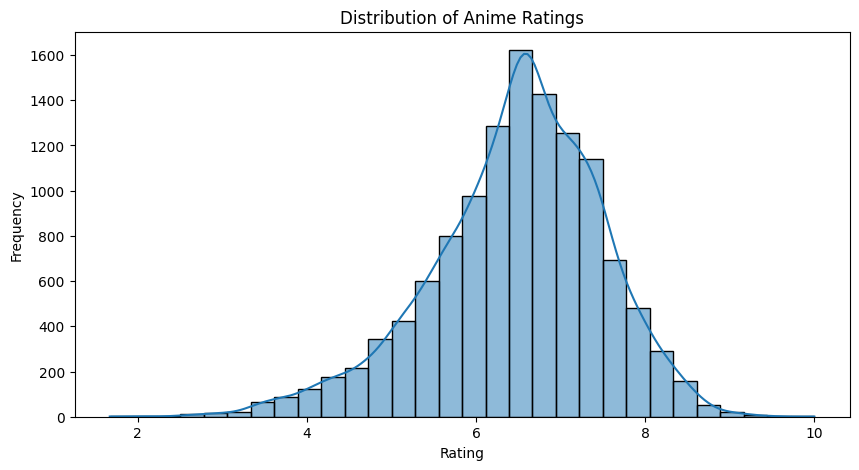

In [81]:

# Distribution of Anime Ratings

plt.figure(figsize=(10,5))

sns.histplot(
    df["rating"],
    bins=30,
    kde=True
)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

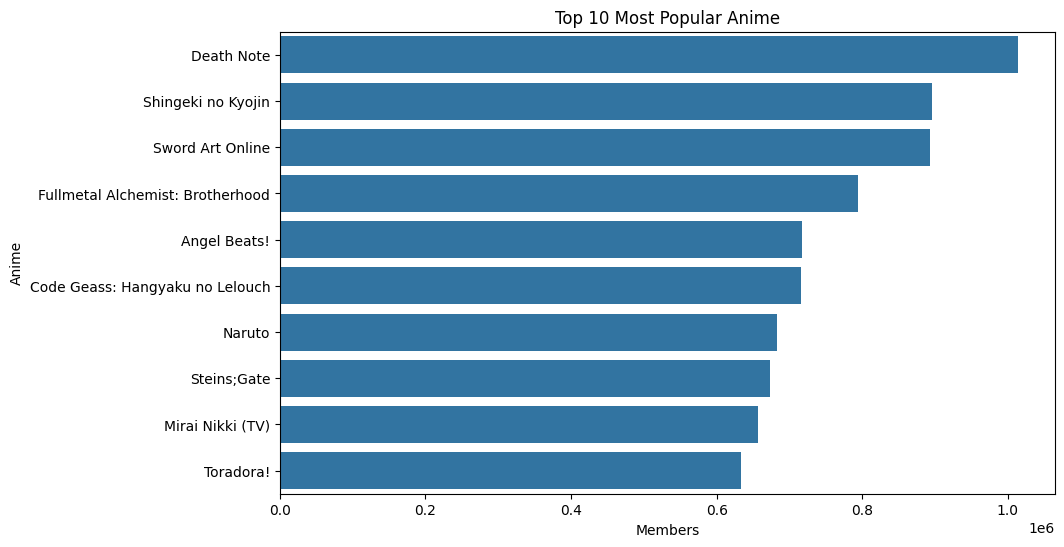

In [82]:

# Top 10 Most Popular Anime

top_members = df.nlargest(10, "members")

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_members,
    x="members",
    y="name"
)

plt.title("Top 10 Most Popular Anime")
plt.xlabel("Members")
plt.ylabel("Anime")

plt.show()

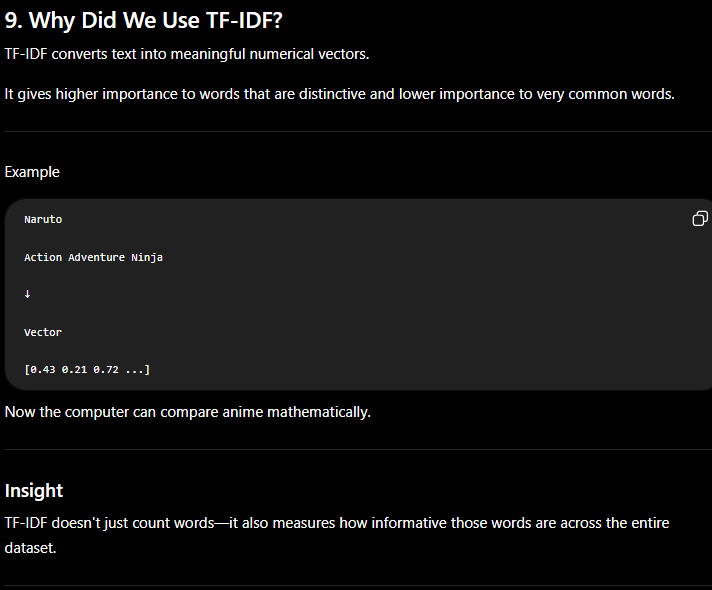

TF-IDF converts textual genre information into numerical vectors by assigning higher importance to unique words and lower importance to common words.

 These vectors allow mathematical similarity calculations.

In [83]:

# Feature Extraction using TF-IDF

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words="english")

# Convert Genre column into numerical vectors
genre_matrix = tfidf.fit_transform(df["genre"])

# Display Shape
print("TF-IDF Matrix Shape :", genre_matrix.shape)

TF-IDF Matrix Shape : (12294, 47)


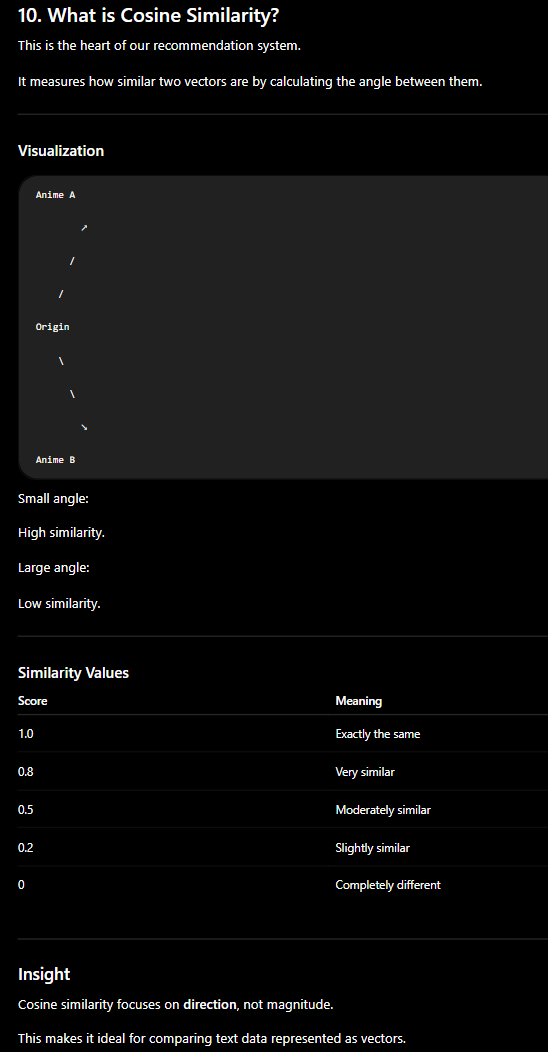

In [84]:

# Calculate Cosine Similarity

cosine_sim = cosine_similarity(genre_matrix)

print(cosine_sim.shape)

(12294, 12294)


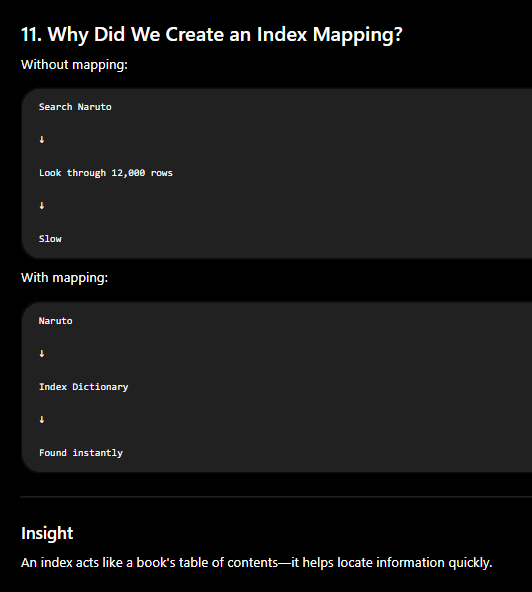

In [85]:

# Create Anime Index


anime_index = pd.Series(df.index, index=df["name"]).drop_duplicates()

anime_index.head()

,0
name,
Kimi no Na wa.,0
Fullmetal Alchemist: Brotherhood,1
Gintama°,2
Steins;Gate,3
Gintama&#039;,4


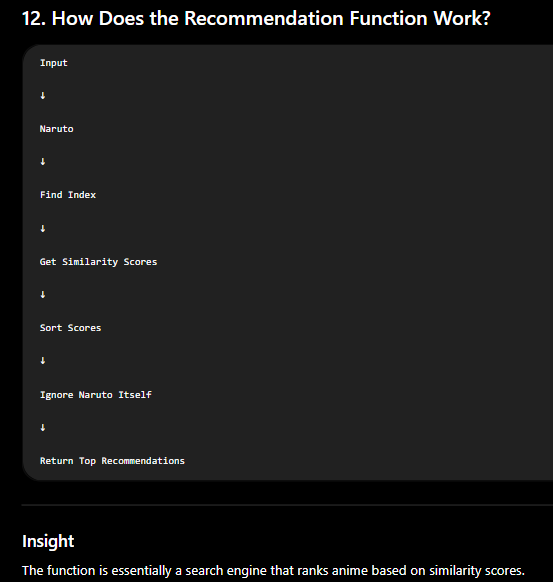

In [86]:

# Recommendation Function


def recommend_anime(anime_name, top_n=10):

    # Check whether anime exists
    if anime_name not in anime_index:
        return "Anime not found."

    # Get index of selected anime
    idx = anime_index[anime_name]

    # Calculate similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort based on similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Ignore first anime (itself)
    similarity_scores = similarity_scores[1:top_n+1]

    # Get anime indices
    anime_indices = [i[0] for i in similarity_scores]

    # Display Recommendations
    return df[["name", "genre", "rating"]].iloc[anime_indices]

In [87]:
recommend_anime("Naruto")

,name,genre,rating
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",7.81
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.68
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",7.58
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53
1573,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.50
2458,Naruto Shippuuden: Sunny Side Battle,"Action, Comedy, Martial Arts, Shounen, Super P...",7.26
2997,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.11
7628,Kyutai Panic Adventure!,"Action, Martial Arts, Shounen, Super Power",5.21
784,Naruto: Shippuuden Movie 6 - Road to Ninja,"Action, Adventure, Martial Arts, Shounen, Supe...",7.84


In [88]:
recommend_anime("One Piece")

,name,genre,rating
231,One Piece: Episode of Merry - Mou Hitori no Na...,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",8.29
241,One Piece: Episode of Nami - Koukaishi no Nami...,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",8.27
896,One Piece: Episode of Sabo - 3 Kyoudai no Kizu...,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",7.78
352,One Piece Film: Strong World Episode 0,"Action, Adventure, Comedy, Fantasy, Shounen, S...",8.16
753,One Piece: Episode of Luffy - Hand Island no B...,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.86
941,One Piece Movie 4: Dead End no Bouken,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.76
1171,One Piece Movie 9: Episode of Chopper Plus - F...,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.65
1576,One Piece: Adventure of Nebulandia,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.50
1793,One Piece Movie 5: Norowareta Seiken,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.44
1795,One Piece: Umi no Heso no Daibouken-hen,"Action, Adventure, Comedy, Fantasy, Shounen, S...",7.44


In [89]:
recommend_anime("Death Note")

,name,genre,rating
778,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",7.84
981,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",7.74
144,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",8.41
1383,Higurashi no Naku Koro ni Rei,"Comedy, Mystery, Psychological, Supernatural, ...",7.56
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",8.07
4164,Mirai Nikki (TV): Ura Mirai Nikki,"Action, Comedy, Mystery, Psychological, Shoune...",6.79
334,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",8.17
38,Monster,"Drama, Horror, Mystery, Police, Psychological,...",8.72
5382,AD Police,"Adventure, Dementia, Mecha, Mystery, Police, P...",6.47
2074,Higurashi no Naku Koro ni Kaku: Outbreak,"Horror, Mystery, Psychological, Thriller",7.36


In [90]:
recommend_anime("Bleach")

,name,genre,rating
946,Bleach Movie 4: Jigoku-hen,"Action, Comedy, Shounen, Super Power, Supernat...",7.75
1131,Bleach Movie 3: Fade to Black - Kimi no Na wo ...,"Action, Comedy, Shounen, Super Power, Supernat...",7.66
3288,Code:Breaker,"Action, Comedy, School, Shounen, Super Power, ...",7.03
1244,Yozakura Quartet: Tsuki ni Naku,"Action, Comedy, Magic, Shounen, Super Power, S...",7.62
1271,Yozakura Quartet: Hana no Uta,"Action, Comedy, Magic, Shounen, Super Power, S...",7.61
1694,Yozakura Quartet: Hoshi no Umi,"Action, Comedy, Magic, Shounen, Super Power, S...",7.47
3543,Yozakura Quartet,"Action, Comedy, Magic, Shounen, Super Power, S...",6.96
175,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",8.37
611,K: Missing Kings,"Action, Super Power, Supernatural",7.94
814,K: Return of Kings,"Action, Super Power, Supernatural",7.82


In [91]:

# Recommendation Function with Similarity Scores


def recommend_anime(anime_name, top_n=10):

    if anime_name not in anime_index:
        return "Anime not found."

    idx = anime_index[anime_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    anime_indices = [i[0] for i in similarity_scores]
    scores = [round(i[1],3) for i in similarity_scores]

    recommendations = df[["name","genre","rating"]].iloc[anime_indices].copy()

    recommendations["Similarity Score"] = scores

    return recommendations

In [92]:
recommend_anime("Naruto", top_n=10)

,name,genre,rating,Similarity Score
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94,1.000
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",7.81,1.000
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.68,1.000
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",7.58,1.000
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53,1.000
1573,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.50,1.000
2458,Naruto Shippuuden: Sunny Side Battle,"Action, Comedy, Martial Arts, Shounen, Super P...",7.26,1.000
2997,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.11,1.000
7628,Kyutai Panic Adventure!,"Action, Martial Arts, Shounen, Super Power",5.21,0.981
784,Naruto: Shippuuden Movie 6 - Road to Ninja,"Action, Adventure, Martial Arts, Shounen, Supe...",7.84,0.947


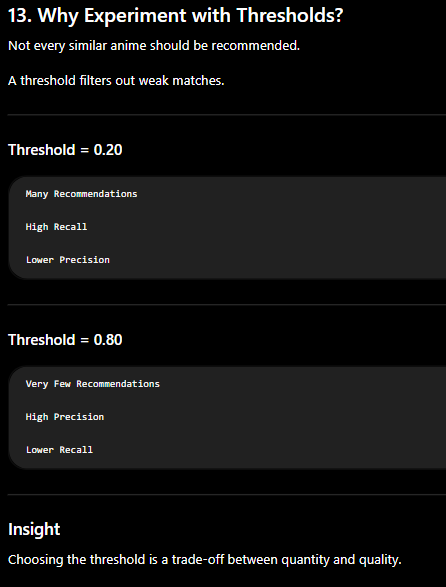

In [93]:

# Recommendation using Similarity Threshold


def recommend_with_threshold(anime_name, threshold=0.30):

    if anime_name not in anime_index:
        return "Anime not found."

    idx = anime_index[anime_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    filtered_scores = [
        score for score in similarity_scores
        if score[1] >= threshold
    ]

    filtered_scores = sorted(
        filtered_scores,
        key=lambda x: x[1],
        reverse=True
    )

    filtered_scores = filtered_scores[1:]

    anime_indices = [i[0] for i in filtered_scores]
    scores = [round(i[1],3) for i in filtered_scores]

    recommendations = df[["name","genre","rating"]].iloc[anime_indices].copy()
    recommendations["Similarity Score"] = scores

    return recommendations

In [94]:
recommend_with_threshold("Naruto", threshold=0.20)

,name,genre,rating,Similarity Score
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94,1.000
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",7.81,1.000
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.68,1.000
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",7.58,1.000
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53,1.000
...,...,...,...,...
6303,The Borgman: Last Battle,"Action, Demons, Sci-Fi, Shounen",6.18,0.201
6375,Chouon Senshi Borgman 2: Shin Seiki 2058,"Action, Demons, Sci-Fi, Shounen",6.14,0.201
6637,Chouon Senshi Borgman: Lovers Rain,"Action, Demons, Sci-Fi, Shounen",6.02,0.201
2298,Jigoku Sensei Nube OVA,"Action, Comedy, Demons, Horror, School, Shoune...",7.30,0.201


In [95]:
recommend_with_threshold("Naruto", threshold=0.40)

,name,genre,rating,Similarity Score
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94,1.000
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",7.81,1.000
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.68,1.000
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",7.58,1.000
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53,1.000
...,...,...,...,...
3941,Gegege no Kitarou (1971),"Adventure, Demons, Super Power, Supernatural",6.84,0.410
8630,Gegege no Kitarou: Kitarou no Yuurei Densha,"Adventure, Demons, Super Power, Supernatural",5.91,0.410
6491,Miracle Shoujo Limit-chan,"Comedy, Magic, School, Sci-Fi, Shoujo, Super P...",6.09,0.408
4406,Kämpfer,"Action, Comedy, Ecchi, Romance, School, Shoujo...",6.73,0.404


In [96]:
recommend_with_threshold("Naruto", threshold=0.60)

,name,genre,rating,Similarity Score
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",7.94,1.000
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",7.81,1.000
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",7.68,1.000
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",7.58,1.000
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",7.53,1.000
...,...,...,...,...
2503,Shin Hakkenden,"Action, Adventure, Martial Arts, Sci-Fi",7.25,0.603
7520,Tekken,"Action, Adventure, Martial Arts, Sci-Fi",5.35,0.603
4548,Beast Wars Neo,"Action, Adventure, Mecha, Shounen, Super Power",6.69,0.602
10629,Ucchare Goshogawara,"Martial Arts, School, Shounen, Sports",5.83,0.601


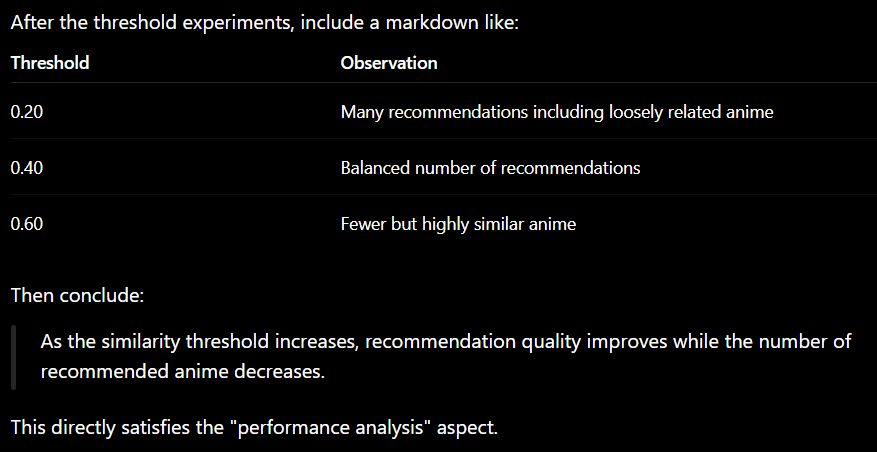

####Conclusion

1. Loaded and explored the anime dataset.
2. Handled missing values and duplicates.
3. Converted the genre text into numerical vectors using TF-IDF.
4. Computed cosine similarity between all anime.
5. Built a content-based recommendation system.
6. Generated recommendations based on genre similarity.
7. Tested different similarity thresholds to control the recommendation list size.

#### Interview Questions

1. Difference between User-Based and Item-Based Collaborative Filtering

| User-Based Collaborative Filtering       | Item-Based Collaborative Filtering            |
| ---------------------------------------- | --------------------------------------------- |
| Finds users with similar preferences.    | Finds items that are similar to each other.   |
| Recommends items liked by similar users. | Recommends items similar to the current item. |
| Similarity is computed between users.    | Similarity is computed between items.         |
| Slower on very large datasets.           | More scalable and commonly used.              |


2. What is Collaborative Filtering?

Collaborative Filtering is a recommendation technique that predicts a user's interests by analyzing the preferences and behaviors of many users. Instead of using item features (like genres), it relies on user-item interactions such as ratings, purchases, or watch history. Users with similar tastes are assumed to enjoy similar items.